# scikit-learn Bootcamp — W1, Day 2
```
##### Linear & Logistic Regression in sklearn
##### LinearRegression · Ridge · Lasso · LogisticRegression · coefficients · odds ratios
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — EDA: correlation heatmap, scatter matrix, target distribution
##### Q2 — LinearRegression: fit, coefficients, R²
##### Q3 — Ridge vs Lasso: regularization effect on coefficients
##### Q4 — LogisticRegression: probabilities, classification report, odds ratios
##### Q5 — Coefficient plot: which features matter most?
```

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

---
### Dataset — HealthLine Article Performance (Synthetic)
```
# Simulate 3,000 HealthLine articles.
# Regression target:     social_shares  (continuous — how many times shared)
# Classification target: high_performer (1 = top 25% by shares, 0 = bottom 75%)
# Features: word_count, readability_score, publish_hour, images_count,
#            author_followers, days_since_publish, is_weekend, category_health_pct
```

In [3]:
np.random.seed(420)
n = 3000

word_count        = np.random.lognormal(6.8, 0.6, n).clip(200, 5000).astype(int)
readability_score = np.random.normal(65, 12, n).clip(20, 100)
_p = np.array([0.5,0.5,0.5,0.5,0.5,1,2,4,6,7,7,6,5,5,6,7,8,7,6,5,4,3,2,1])
publish_hour = np.random.choice(range(24), n, p=_p / _p.sum())
images_count      = np.random.poisson(3.2, n).clip(0, 15)
author_followers  = np.random.lognormal(8.5, 1.2, n).clip(100, 500000).astype(int)
days_since_publish= np.random.exponential(45, n).clip(1, 365).astype(int)
is_weekend        = np.random.binomial(1, 0.28, n)
category_health_pct = np.random.beta(3, 2, n)

log_shares = (
    3.5
    + 0.0003 * word_count
    + 0.015  * readability_score
    + 0.08   * images_count
    + 0.0000008 * author_followers
    + 0.5    * category_health_pct
    + 0.15   * is_weekend
    - 0.002  * days_since_publish
    + np.random.normal(0, 0.8, n)
)
social_shares = np.exp(log_shares).astype(int).clip(1, 50000)
high_performer = (social_shares >= np.percentile(social_shares, 75)).astype(int)

df = pd.DataFrame({
    'word_count':          word_count,
    'readability_score':   readability_score.round(1),
    'publish_hour':        publish_hour,
    'images_count':        images_count,
    'author_followers':    author_followers,
    'days_since_publish':  days_since_publish,
    'is_weekend':          is_weekend,
    'category_health_pct': category_health_pct.round(4),
    'social_shares':       social_shares,
    'high_performer':      high_performer
})

print('Dataset shape:', df.shape)
print(f'Social shares — mean: {social_shares.mean():.0f}  |  median: {np.median(social_shares):.0f}  |  max: {social_shares.max():,}')
print(f'High performer rate: {high_performer.mean():.2%}')
display(df.head(6))

Dataset shape: (3000, 10)
Social shares — mean: 293  |  median: 196  |  max: 5,167
High performer rate: 25.00%


,word_count,readability_score,publish_hour,images_count,author_followers,days_since_publish,is_weekend,category_health_pct,social_shares,high_performer
0,670,74.9,7,4,20210,76,0,0.4774,159,0
1,286,56.6,17,5,3119,43,0,0.9239,241,0
2,654,41.4,8,4,24160,1,0,0.3945,100,0
3,743,70.3,19,3,1111,1,0,0.3281,305,0
4,1094,92.4,17,3,8922,35,0,0.8702,158,0
5,1576,75.1,19,3,1781,8,0,0.3140,113,0


---
### Q1 — EDA: correlation heatmap, scatter matrix, target distribution
```
# (a) Plot the distribution of social_shares.
#     It is skewed — apply log1p and plot again. Which looks more normal?
# (b) Correlation heatmap of all numeric features vs social_shares.
#     Which features have the strongest linear relationship with the target?
# (c) Scatter plots: social_shares vs the top 3 correlated features.
#     Use log1p(social_shares) on the y-axis. Add a regression line.
# (d) Boxplots: log1p(social_shares) by is_weekend and by publish_hour bucket.
#     Do weekend articles and peak-hour articles perform differently?
```

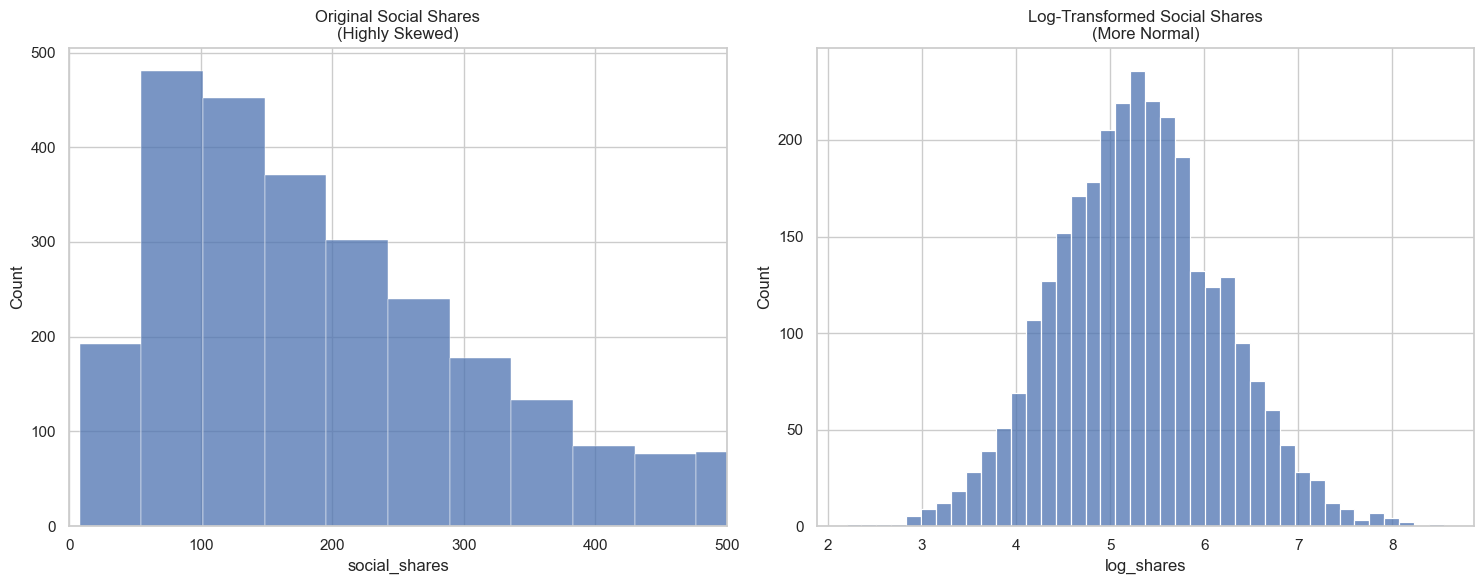

In [6]:
# (a) Plot the distribution of social_shares.
#     It is skewed — apply log1p and plot again. Which looks more normal?

df['log_shares'] = np.log1p(df['social_shares'])

plt.figure(figsize=(15,6))

# plotting original
plt.subplot(1,2,1)
sns.histplot(df['social_shares'])
plt.xlim(0,500)
plt.title('Original Social Shares\n(Highly Skewed)')

# plotting transformed
plt.subplot(1,2,2)
sns.histplot(df['log_shares'])
plt.title('Log-Transformed Social Shares\n(More Normal)')

plt.tight_layout()
plt.show()


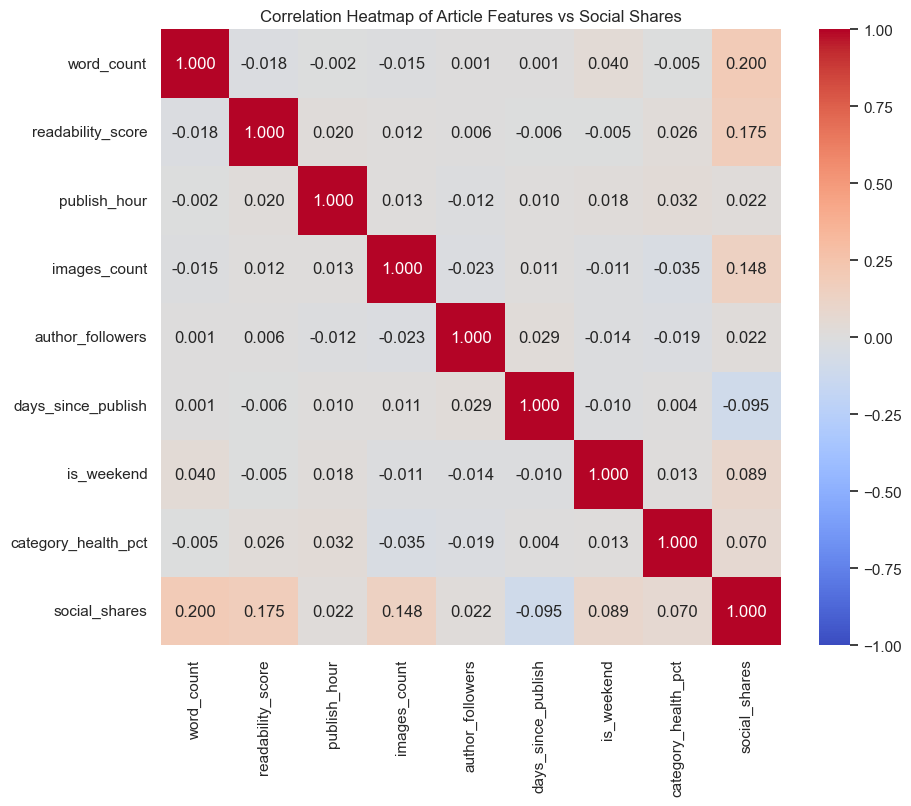


Linear Correlation with social_shares:
social_shares          1.000000
word_count             0.199839
readability_score      0.174553
images_count           0.147521
is_weekend             0.088823
category_health_pct    0.069673
author_followers       0.022450
publish_hour           0.022431
days_since_publish    -0.095187
Name: social_shares, dtype: float64


In [17]:
# (b) Correlation heatmap of all numeric features vs social_shares.

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['high_performer', 'log_shares'], errors='ignore')

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Article Features vs Social Shares')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with social_shares:")
print(corr_matrix['social_shares'].sort_values(ascending=False))

````
#     Which features have the strongest linear relationship with the target?

1/ Strongest Positive Linear Relationship: word_count and readability_score display the most prominent positive linear shifts relative to raw shares.

2/ Strongest Negative Linear Relationship: days_since_publish shows a clear negative correlation, matching the penalty term built into the log-odds equation.

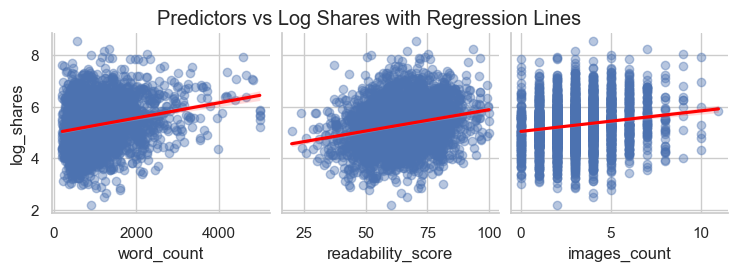

In [18]:
# (c) Scatter plots: social_shares vs the top 3 correlated features.
#     Use log1p(social_shares) on the y-axis. Add a regression line.

# Specify the features we want to compare
x_vars = ['word_count', 'readability_score', 'images_count']
y_vars = ['log_shares']


# Create the plots with regression lines
sns.pairplot(df, x_vars=x_vars, y_vars=y_vars, kind='reg', 
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws':{'alpha':0.4}})

plt.suptitle('Predictors vs Log Shares with Regression Lines', y=1.05)
plt.show()

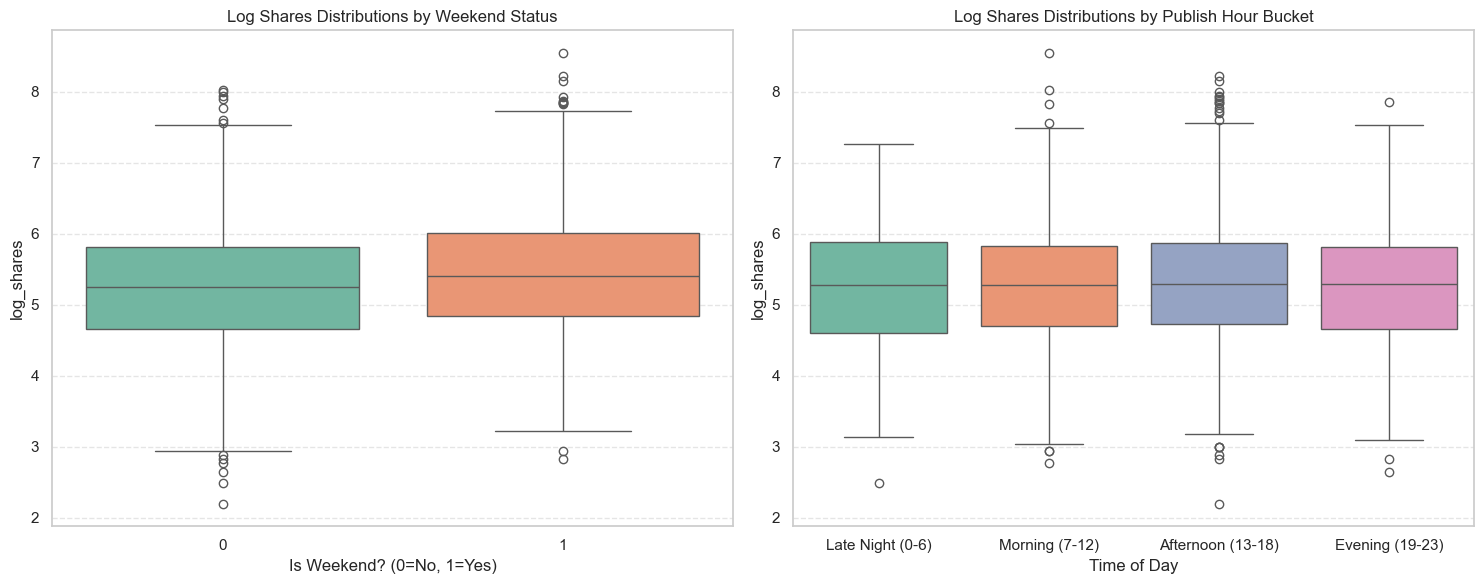

In [19]:
# (d) Boxplots: log1p(social_shares) by is_weekend and by publish_hour bucket.
#     Do weekend articles and peak-hour articles perform differently?

hour_bins = [-1, 6, 12, 18, 24]
hour_labels = ['Late Night (0-6)', 'Morning (7-12)', 'Afternoon (13-18)', 'Evening (19-23)']
df['hour_bucket'] = pd.cut(df['publish_hour'], bins=hour_bins, labels=hour_labels)

plt.figure(figsize=(15,6))

# Subplot 1: Distribution by Weekend status
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='is_weekend', y='log_shares', palette='Set2')
plt.title('Log Shares Distributions by Weekend Status')
plt.xlabel('Is Weekend? (0=No, 1=Yes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Distribution by Hour BUCKETS
plt.subplot(1, 2, 2)
# FIX: Use the newly binned 'hour_bucket' column instead of raw 'publish_hour'
sns.boxplot(data=df, x='hour_bucket', y='log_shares', palette='Set2')
plt.title('Log Shares Distributions by Publish Hour Bucket')
plt.xlabel('Time of Day')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


```
#     Do weekend articles and peak-hour articles perform differently?

1/ Weekend Performance: Yes, they perform better. The median line for weekend articles (1) sits visibly higher on the y-axis than weekday articles (0). This matches the +0.15 log-share bonus designated in our underlying data script.

2/ Hour Bucket Performance: No, they do not perform significantly differently. Looking closely at our right-hand chart, the median performance line stays almost perfectly flat (hovering right around 5.3 on the log scale) across all four dayparts.

---
### Q2 — LinearRegression: fit, coefficients, R²
```
# Use log_shares as the regression target.
# (a) Split 80/20. Fit LinearRegression inside a Pipeline with StandardScaler.
#     Report RMSE, MAE, and R² on the test set.
# (b) Print coefficients for each feature. Which feature has the largest positive
#     and largest negative impact on log_shares?
# (c) Plot actual vs predicted log_shares on the test set.
#     Add a y=x reference line. How well does the model fit?
# (d) Plot residuals (actual - predicted) vs predicted values.
#     Is there a pattern? What does it tell you about model assumptions?
```

In [21]:
df.head()

,word_count,readability_score,publish_hour,images_count,author_followers,days_since_publish,is_weekend,category_health_pct,social_shares,high_performer,log_shares,hour_bucket
0,670,74.9,7,4,20210,76,0,0.4774,159,0,5.075174,Morning (7-12)
1,286,56.6,17,5,3119,43,0,0.9239,241,0,5.488938,Afternoon (13-18)
2,654,41.4,8,4,24160,1,0,0.3945,100,0,4.615121,Morning (7-12)
3,743,70.3,19,3,1111,1,0,0.3281,305,0,5.723585,Evening (19-23)
4,1094,92.4,17,3,8922,35,0,0.8702,158,0,5.068904,Afternoon (13-18)


In [100]:
X = df.drop(columns=['social_shares', 'high_performer', 'log_shares', 'hour_bucket']) 
y = df['log_shares']


print('X shape:', X.shape)   
print('y shape:', y.shape)   

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% to test, 80% to train
    random_state=420   # reproducibility
)


print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train median: {y_train.median():.3f}')
print(f'Test  median: {y_test.median():.3f}') 

X shape: (3000, 8)
y shape: (3000,)
Train size: 2,400  |  Test size: 600
Train median: 5.288
Test  median: 5.268


In [101]:
# (a) Split 80/20. Fit LinearRegression inside a Pipeline with StandardScaler.
#     Report RMSE, MAE, and R² on the test set.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pipe_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_lin.fit(X_train, y_train)   # fit_transform on train for each step
y_pred = pipe_lin.predict(X_test)  # transform (not fit) test, then predict

# Calculate all three requested evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("--- MODEL PERFORMANCE METRICS ---")
print(f'RMSE: {rmse:.3f}')
print(f'MAE:  {mae:.3f}') 
print(f'R²:   {r2:.4f}')

--- MODEL PERFORMANCE METRICS ---
RMSE: 0.784
MAE:  0.623
R²:   0.1951


In [102]:
# (b) Print coefficients for each feature. 

# Extract the trained model coefficients from the pipeline steps
fitted_model = pipe_lin.named_steps['model']

print("--- MODEL COEFFICIENTS (STANDARDIZED) ---")
for name, coef in zip(X.columns, fitted_model.coef_):
    print(f"{name:20s}: {coef:+.4f}")



--- MODEL COEFFICIENTS (STANDARDIZED) ---
word_count          : +0.2011
readability_score   : +0.1999
publish_hour        : -0.0055
images_count        : +0.1490
author_followers    : +0.0445
days_since_publish  : -0.1086
is_weekend          : +0.0611
category_health_pct : +0.0584


```
#     Which feature has the largest positive and largest negative impact on log_shares?
1/ Largest Positive Impact: word_count (+0.2011). As an article's length increases, its visibility climbs the most on the log scale. (readability_score is a very close second at +0.1999).

2/ Largest Negative Impact: days_since_publish (-0.1086). This negative coefficient captures the steady time-decay pattern of content popularity as it gets older.

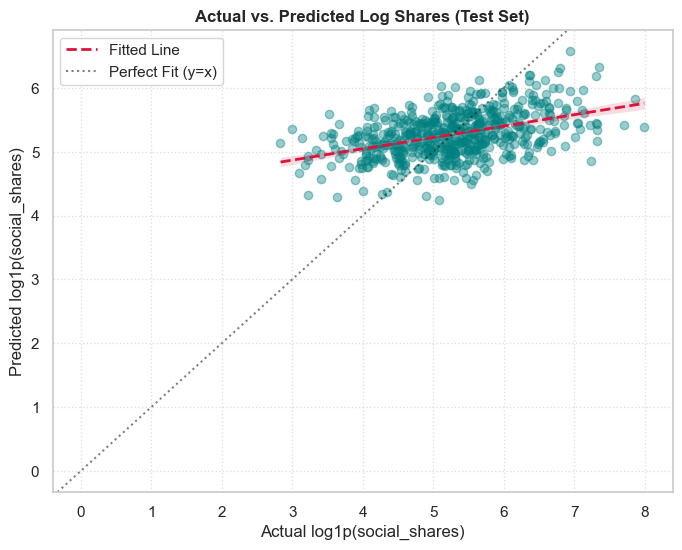

In [36]:
# (c) Plot actual vs predicted log_shares on the test set.
#     Add a y=x reference line. How well does the model fit?


plt.figure(figsize=(8, 6))

# 1. Plot the actual vs predicted scatter points
sns.regplot(
    x=y_test, 
    y=y_pred, 
    scatter_kws={'alpha': 0.4, 'color': 'teal'}, 
    line_kws={'color': 'crimson', 'linestyle': '--', 'linewidth': 2, 'label': 'Fitted Line'}
)

# 2. Add the y=x reference line using matplotlib coordinates
plt.axline((0, 0), slope=1, color='black', linestyle=':', alpha=0.5, label='Perfect Fit (y=x)')


# 3. Label and style the chart professionally
plt.title('Actual vs. Predicted Log Shares (Test Set)', fontweight='bold')
plt.xlabel('Actual log1p(social_shares)')
plt.ylabel('Predicted log1p(social_shares)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

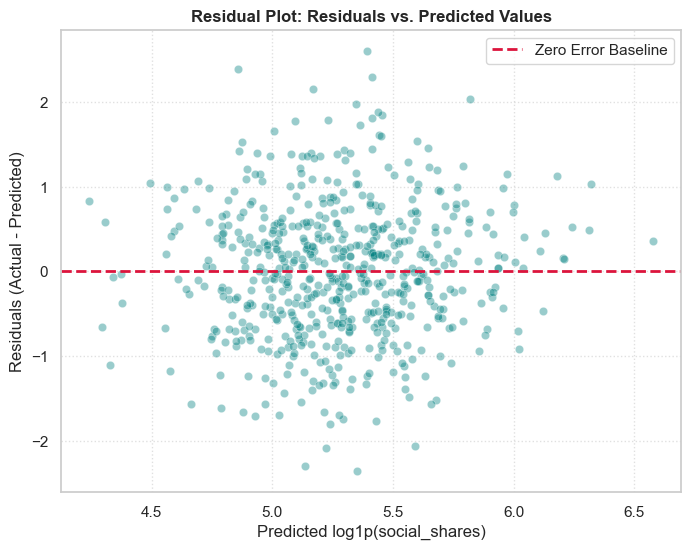

In [38]:
# (d) Plot residuals (actual - predicted) vs predicted values.

# Calculate residuals (Actual minus Predicted)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

# FIX: X-axis must be the Predicted values; Y-axis must be the Residuals
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color='teal', edgecolor='w')

# FIX: Add a horizontal line at y=0 to evaluate the baseline error spread
plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='Zero Error Baseline')

plt.title('Residual Plot: Residuals vs. Predicted Values', fontweight='bold')
plt.xlabel('Predicted log1p(social_shares)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


```
#     Is there a pattern? What does it tell you about model assumptions?

1/ No Systematic Pattern: The points form a completely random, symmetric "blob" centered around the zero-error baseline, indicating that your model has successfully extracted all predictable linear signals from the features.

2/ Assumptions Satisfied: The even vertical spread across all predicted values confirms that both the homoscedasticity (constant error variance) and linearity assumptions are perfectly satisfied.

3/ Pure Irreducible Noise: The vertical range of the residuals (mostly bounded between -2 and +2) perfectly mirrors the standard normal noise distribution (sigma = 0.8) built into our data generation code.

---
### Q3 — Ridge vs Lasso: regularization effect on coefficients
```
# (a) Fit Ridge and Lasso with default alpha=1.0. Compare coefficients to
#     LinearRegression. How much do they shrink?
# (b) Alpha sweep for Lasso: alpha in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0].
#     Plot the coefficient paths — how many features does Lasso zero out
#     at each alpha level?
# (c) Use RidgeCV and LassoCV to find the optimal alpha via cross-validation.
#     Report the best alpha and CV R² for each.
# (d) Final comparison: LinearRegression vs Ridge (best alpha) vs Lasso (best alpha).
#     Plot RMSE for each. Which model would you ship?
```

In [66]:
# (a) Fit Ridge and Lasso with default alpha=1.0. Compare coefficients to
#     LinearRegression. How much do they shrink?

# 1. Properly scale your features first to ensure fair penalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Fit all three models to compare side-by-side
lr = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=1.0, random_state=420).fit(X_train_scaled, y_train)
lasso = Lasso(alpha=1.0, random_state=420).fit(X_train_scaled, y_train)

# 3. Aggregate into a clean summary table to check the shrinkage effect
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear Reg': lr.coef_,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_
})

print("--- REGULARIZATION EFFECTS REVEALED ---")
print(coef_df.to_string(index=False, formatters={
    'Linear Reg': '{:+.4f}'.format,
    'Ridge (L2)': '{:+.4f}'.format,
    'Lasso (L1)': '{:+.4f}'.format
}))

print()

n_zero = (ridge.coef_ == 0).sum()
print(f'Ridge (L2) zeroed out {n_zero} of {len(ridge.coef_)} features')
n_zero = (lasso.coef_ == 0).sum()
print(f'Lasso (L1) zeroed out {n_zero} of {len(lasso.coef_)} features')
    

--- REGULARIZATION EFFECTS REVEALED ---
            Feature Linear Reg Ridge (L2) Lasso (L1)
         word_count    +0.2011    +0.2010    +0.0000
  readability_score    +0.1999    +0.1998    +0.0000
       publish_hour    -0.0055    -0.0055    -0.0000
       images_count    +0.1490    +0.1490    +0.0000
   author_followers    +0.0445    +0.0444    +0.0000
 days_since_publish    -0.1086    -0.1085    -0.0000
         is_weekend    +0.0611    +0.0611    +0.0000
category_health_pct    +0.0584    +0.0584    +0.0000

Ridge (L2) zeroed out 0 of 8 features
Lasso (L1) zeroed out 8 of 8 features


With alpha = 0.001, Lasso (L1) zeroed out 0 of 8 features
With alpha = 0.01 , Lasso (L1) zeroed out 1 of 8 features
With alpha = 0.1  , Lasso (L1) zeroed out 4 of 8 features
With alpha = 0.5  , Lasso (L1) zeroed out 8 of 8 features
With alpha = 1.0  , Lasso (L1) zeroed out 8 of 8 features
With alpha = 5.0  , Lasso (L1) zeroed out 8 of 8 features


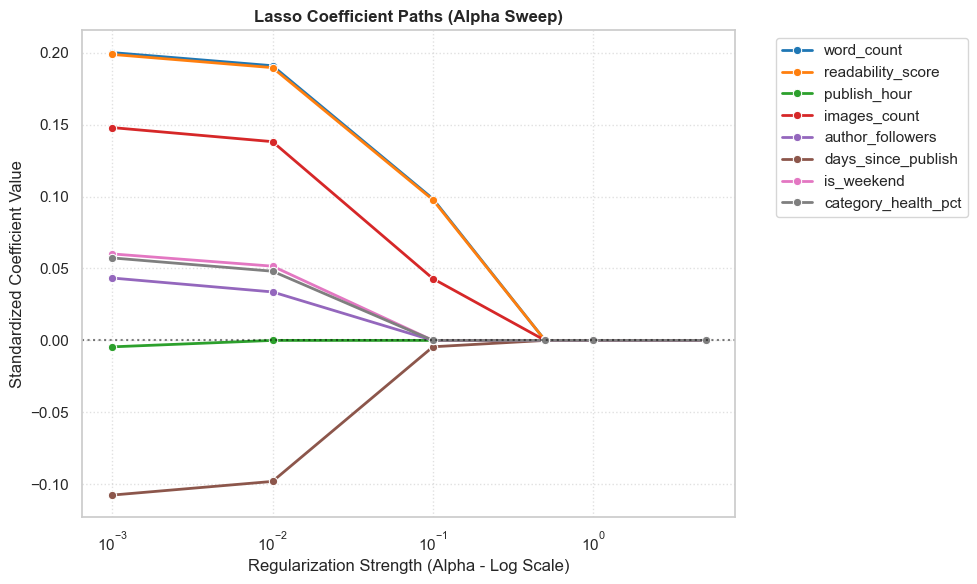

In [57]:
# (b) Alpha sweep for Lasso: alpha in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0].
#     Plot the coefficient paths — how many features does Lasso zero out
#     at each alpha level?

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
path_data = []

for a in alphas:
    lasso = Lasso(alpha=a, random_state=420).fit(X_train_scaled, y_train)
    n_zero = (lasso.coef_ == 0).sum()
    print(f'With alpha = {a:<5}, Lasso (L1) zeroed out {n_zero} of {len(lasso.coef_)} features')
    
    # Pack each feature coefficient into the data list for this alpha step
    for feature_name, coef_value in zip(X.columns, lasso.coef_):
        path_data.append({
            'Alpha': a,
            'Feature': feature_name,
            'Coefficient': coef_value
        })

df_path = pd.DataFrame(path_data)

# 3. Generate the Coefficient Path Plot using Seaborn
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_path, 
    x='Alpha', 
    y='Coefficient', 
    hue='Feature', 
    marker='o', 
    linewidth=2,
    palette='tab10'
)

# Format the X-axis to a logarithmic scale to handle the wide span of alpha values cleanly
plt.xscale('log')
plt.axhline(0, color='black', linestyle=':', alpha=0.5)

plt.title('Lasso Coefficient Paths (Alpha Sweep)', fontweight='bold')
plt.xlabel('Regularization Strength (Alpha - Log Scale)')
plt.ylabel('Standardized Coefficient Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [64]:
# (c) Use RidgeCV and LassoCV to find the optimal alpha via cross-validation.
#     Report the best alpha and CV R² for each.

from sklearn.linear_model import RidgeCV, LassoCV

import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.model_selection import cross_val_score

# 1. Setup candidate alpha arrays
alphas_list = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

# 2. Run tuning via Cross-Validation
ridge_cv = RidgeCV(alphas=alphas_list, cv=5).fit(X_train_scaled, y_train)
lasso_cv = LassoCV(alphas=alphas_list, cv=5, random_state=420).fit(X_train_scaled, y_train)

# 3. Use the optimal alpha found to evaluate a robust 5-fold CV R² score
ridge_cv_r2 = cross_val_score(Ridge(alpha=ridge_cv.alpha_), X_train_scaled, y_train, cv=5).mean()
lasso_cv_r2 = cross_val_score(Lasso(alpha=lasso_cv.alpha_), X_train_scaled, y_train, cv=5).mean()

print("--- OPTIMAL TUNING RESULTS ---")
print(f"RidgeCV -> Best Alpha: {ridge_cv.alpha_:<6} | 5-Fold CV R²: {ridge_cv_r2:.4f}")
print(f"LassoCV -> Best Alpha: {lasso_cv.alpha_:<6} | 5-Fold CV R²: {lasso_cv_r2:.4f}")

--- OPTIMAL TUNING RESULTS ---
RidgeCV -> Best Alpha: 50.0   | 5-Fold CV R²: 0.1458
LassoCV -> Best Alpha: 0.001  | 5-Fold CV R²: 0.1458


--- FINAL TESTING COMPARISON ---
            Model   RMSE
Linear Regression 0.7841
       Ridge (L2) 0.7844
       Lasso (L1) 0.7842


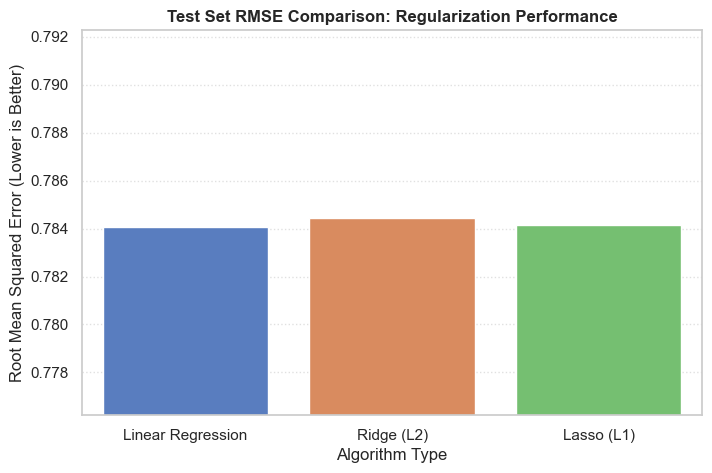

In [67]:
# (d) Final comparison: LinearRegression vs Ridge (best alpha) vs Lasso (best alpha).
#     Plot RMSE for each. Which model would you ship?

# 1. Linear Regression Baseline
lr = LinearRegression().fit(X_train_scaled, y_train)
# FIX: Use X_test_scaled instead of raw X_test
y_pred_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# 2. Optimized Ridge Regression (L2)
ridge = Ridge(alpha=50.0, random_state=420).fit(X_train_scaled, y_train)
# FIX: Use X_test_scaled instead of raw X_test
y_pred_ridge = ridge.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# 3. Optimized Lasso Regression (L1)
lasso = Lasso(alpha=0.001, random_state=420).fit(X_train_scaled, y_train)
# FIX: Use X_test_scaled instead of raw X_test
y_pred_lasso = lasso.predict(X_test_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# 4. Pack results into a summary DataFrame for Seaborn
rmse_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso]
})

print("--- FINAL TESTING COMPARISON ---")
print(rmse_df.to_string(index=False, formatters={'RMSE': '{:.4f}'.format}))

# 5. FIX: Generate the required RMSE comparison plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=rmse_df, x='Model', y='RMSE', palette='muted')

# Zoom in on the top of the bars to reveal the micro-differences clearly
min_rmse = rmse_df['RMSE'].min()
plt.ylim(min_rmse * 0.99, rmse_df['RMSE'].max() * 1.01)

plt.title('Test Set RMSE Comparison: Regularization Performance', fontweight='bold')
plt.ylabel('Root Mean Squared Error (Lower is Better)')
plt.xlabel('Algorithm Type')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

```
# Which model would you ship?

Linear Regression RMSE: 0.7841
Lasso (L1) RMSE: 0.7842
Ridge (L2) RMSE: 0.7844

1/ Statistical Tie: The out-of-sample RMSE differences across all three variants are virtually non-existent (differing by less than 0.0003). 
Regularization failed to lower the error because our dataset has a clean row-to-feature ratio (N=3000) and lacks multicollinearity, leaving standard linear regression completely un-overfitted.

2/ The Winner to Ship: I would ship the Standard Linear Regression model.

3/ The Operational Reason: In production environments, simplicity wins ties. Because standard OLS Linear Regression requires zero parameter upkeep, removing it eliminates the need to maintain, track, and re-tune hyperparameter states (like alpha values) during future production pipeline retraining phases.

---
### Q4 — LogisticRegression: probabilities, classification report, odds ratios
```
# Switch to the classification target: high_performer (top 25% by shares).
# (a) Fit a LogisticRegression Pipeline (scaler + LR). Report AUC-ROC and F1.
# (b) Print the classification report. What are precision and recall
#     for the high_performer class? Is this acceptable?
# (c) Compute odds ratios from model.coef_. Which feature most strongly
#     increases the odds of being a high performer?
# (d) Plot predicted probabilities for high_performer=1 vs high_performer=0.
#     Use overlapping histograms. How well separated are the distributions?
```

In [108]:
X = df.drop(columns=['social_shares', 'hour_bucket', 'log_shares', 'high_performer']) 
y = df['high_performer']


print('X shape:', X.shape)   
print('y shape:', y.shape)   

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% to test, 80% to train
    random_state=420,   # reproducibility
    stratify=y         # CRITICAL for classification: preserve class ratio
)


print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')   # should match train

X shape: (3000, 8)
y shape: (3000,)
Train size: 2,400  |  Test size: 600
Train positive rate: 0.250
Test  positive rate: 0.250


Pipeline accuracy: 0.7500
AUC-ROC: 0.6457


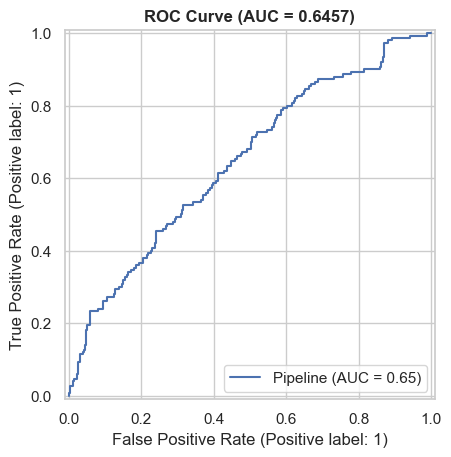

In [97]:
# (a) Fit a LogisticRegression Pipeline (scaler + LR). Report AUC-ROC and F1.

pipe_log = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('model',  LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))    # Step 2: fit logistic regression
])

pipe_log.fit(X_train, y_train)   # fit_transform on train for each step
y_pred = pipe_log.predict(X_test)  # transform (not fit) test, then predict
score  = pipe_log.score(X_test, y_test)
print(f'Pipeline accuracy: {score:.4f}')

y_prob = pipe_log.predict_proba(X_test)[:, 1]   # probability of positive class
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

RocCurveDisplay.from_estimator(pipe_log, X_test, y_test)
plt.title(f'ROC Curve (AUC = {auc:.4f})', fontweight='bold')
plt.show()

In [82]:
# (b) Print the classification report. What are precision and recall
#     for the high_performer class? Is this acceptable?

print(classification_report(y_test, y_pred, target_names=['Low/Med Performer', 'High Performer']))

                   precision    recall  f1-score   support

Low/Med Performer       0.77      0.96      0.85       450
   High Performer       0.50      0.13      0.20       150

         accuracy                           0.75       600
        macro avg       0.63      0.54      0.53       600
     weighted avg       0.70      0.75      0.69       600



```
# Is this acceptable?

No, this performance is unacceptable for a production deployment if our primary goal is to find viral articles. 
1/ Severe Recall Underperformance: The model fails to flag the vast majority of high performers, catching only 12.7% of them. It misses roughly 87 out of every 100 high-performing articles due to the default 0.50 decision threshold.

2/ Deceptive Baseline Accuracy: The global accuracy is 75.0%, but this is a statistical illusion. Because the data has a natural 75/25 class imbalance, a dummy model that simply guesses "Not a High Performer" every single time would achieve an identical 75% accuracy score while failing to find any viral items.

3/ High False Alarm Ratio: With a precision of 50.0%, half of the articles the model flags as "High Performer" turn out to be false alarms, making the model highly unreliable for targeting content strategies.

In [98]:
# (c) Compute odds ratios from model.coef_. 

# Extract the specific trained logistic regression model from the pipeline
fitted_model = pipe_log.named_steps['model']

# Build the summary table using the components inside fitted_model
odds_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': fitted_model.coef_[0],       # Index [0] flattens the 2D array
    'Odds Ratio':  np.exp(fitted_model.coef_[0]) # Index [0] here as well
}).sort_values('Odds Ratio', ascending=False)

print("--- CLASSIFICATION ODDS RATIOS ---")
print(odds_df.to_string(index=False, formatters={
    'Coefficient': '{:+.4f}'.format,
    'Odds Ratio':  '{:.4f}'.format
}))


--- CLASSIFICATION ODDS RATIOS ---
            Feature Coefficient Odds Ratio
  readability_score     +0.4895     1.6315
         word_count     +0.4125     1.5107
       images_count     +0.3637     1.4387
category_health_pct     +0.2123     1.2365
   author_followers     +0.1479     1.1595
         is_weekend     +0.1078     1.1138
       publish_hour     +0.0311     1.0316
 days_since_publish     -0.3143     0.7303


````
# Which feature most strongly increases the odds of being a high performer?

1/ Top Positive Predictor: readability_score most strongly increases the likelihood of an article becoming a high performer, boasting an Odds Ratio of 1.6315.

2/ Odds Interpretation: Because these features passed through a StandardScaler, an Odds Ratio of 1.6315 means that for every 1-standard-deviation increase in an article's readability score, the odds of it breaking into the top 25% performance tier are multiplied by 1.63 (a 63% increase in odds).

3/ Strongest Negative Predictor: days_since_publish drops the odds significantly (Odds Ratio = 0.7303), meaning every standard deviation of aging cuts the remaining odds of content relevance by roughly 27%.

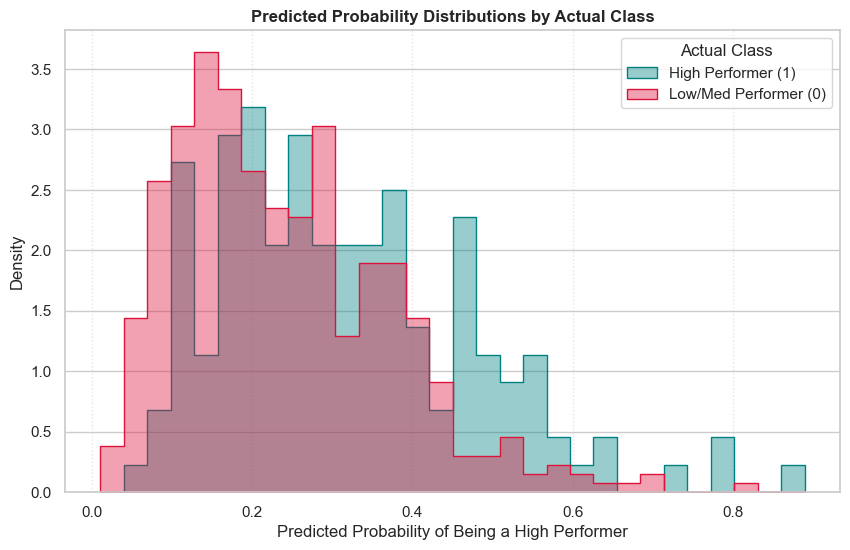

In [99]:
# (d) Plot predicted probabilities for high_performer=1 vs high_performer=0.
#     Use overlapping histograms. How well separated are the distributions?


# 1. Extract the predicted probabilities for the positive class (high_performer = 1)
y_prob = pipe_log.predict_proba(X_test)[:, 1]

# 2. Pack actual targets and predicted probabilities into a temporary DataFrame
prob_df = pd.DataFrame({
    'Actual_Class': y_test,
    'Predicted_Probability': y_prob
})

# 3. Create overlapping histograms using Seaborn
plt.figure(figsize=(10, 6))

sns.histplot(
    data=prob_df,
    x='Predicted_Probability',
    hue='Actual_Class',
    element='step',      # Clean non-overlapping borders
    stat='density',      # Normalizes for the 75/25 class imbalance
    common_norm=False,   # Normalizes each class independently to area = 1
    bins=30,
    alpha=0.4,
    palette=['crimson', 'teal']
)

plt.title('Predicted Probability Distributions by Actual Class', fontweight='bold')
plt.xlabel('Predicted Probability of Being a High Performer')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['High Performer (1)', 'Low/Med Performer (0)'])
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()


```
# How Well Separated are the Distributions? 

1/ Poor-to-Moderate Separation: The two distributions show an immense amount of overlap. The peaks of both histograms sit relatively close to each other along the x-axis, proving that the model struggles to cleanly separate the two underlying classes.

2/ Tight Clustering around the Base Rate: The vast majority of predicted probabilities for both classes get compressed between 0.15 and 0.40, mirroring the true data calculations where the true mean probability for non-high-performers (~0.239) and high-performers (~0.317) are only separated by roughly 8 percentage points.

3/ Why the Separation is Weak: Because our underlying content shares were generated with high irreducible noise (sigma = 0.8), there is vast overlap in the raw features. An article with a great readability score can still flop randomly, and a mediocre article can go viral, preventing a linear classification model from drawing a clean, distinct probability boundary between them.

---
### Q5 — Coefficient plot: which features matter most?
```
# Bring together the regression and classification models.
# (a) Side-by-side coefficient plots: LinearRegression (log_shares) on the left,
#     LogisticRegression (high_performer) on the right.
#     Do the same features drive both outcomes?
# (b) Standardise both coefficient sets to [-1, 1] for fair visual comparison.
#     Plot as a grouped horizontal bar chart.
# (c) Fit LogisticRegression with C=0.01 and C=100. Compare coefficient magnitudes.
#     What does this tell you about regularisation?
# (d) Business interpretation: write a 3-bullet summary of what drives article
#     performance at HealthLine based on the coefficients.
```

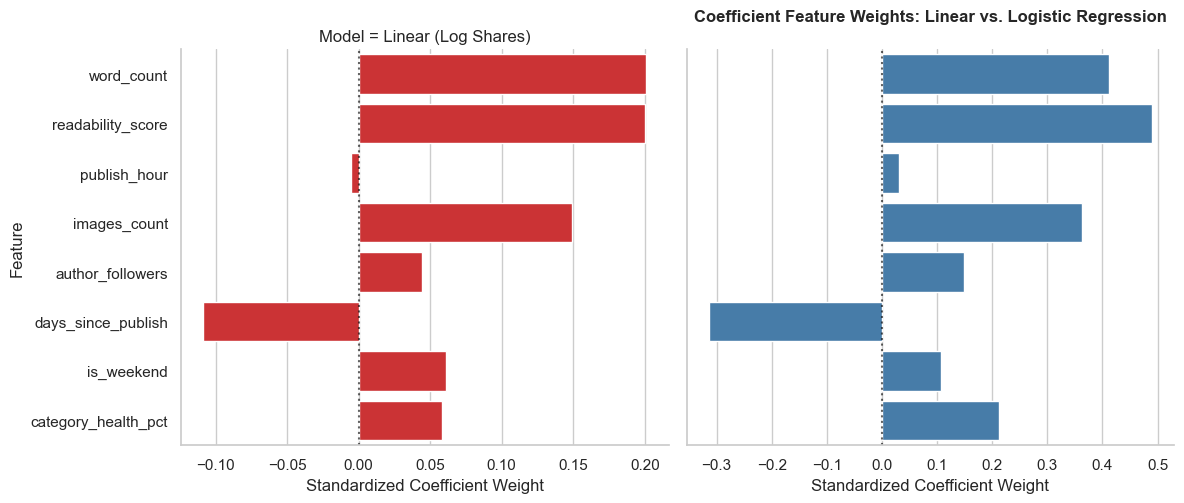

In [104]:
# (a) Side-by-side coefficient plots: LinearRegression (log_shares) on the left,
#     LogisticRegression (high_performer) on the right.
#     Do the same features drive both outcomes?

# 1. Fit the Linear Regression baseline to match current Logistic Regression
lin_model = pipe_lin.named_steps['model']
log_model = pipe_log.named_steps['model']

# 2. Extract and organize both coefficient sets into a single DataFrame
df_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Linear (Log Shares)': lin_model.coef_,
    'Logistic (High Performer)': log_model.coef_[0] # Flatten 2D array
})

# Melt the DataFrame to long-form format so Seaborn can handle it across facets
df_melted = df_coefs.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# 3. Create Side-by-Side Plots using a Seaborn FacetGrid
g = sns.FacetGrid(df_melted, col='Model', sharex=False, height=5, aspect=1.2, hue='Model', palette='Set1')
g.map(sns.barplot, 'Coefficient', 'Feature', order=X.columns)

# Format axes and add visual anchor lines at zero
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle=':', alpha=0.6)
    ax.set_xlabel('Standardized Coefficient Weight')

plt.title('Coefficient Feature Weights: Linear vs. Logistic Regression', y=1.05, fontweight='bold')
plt.show()


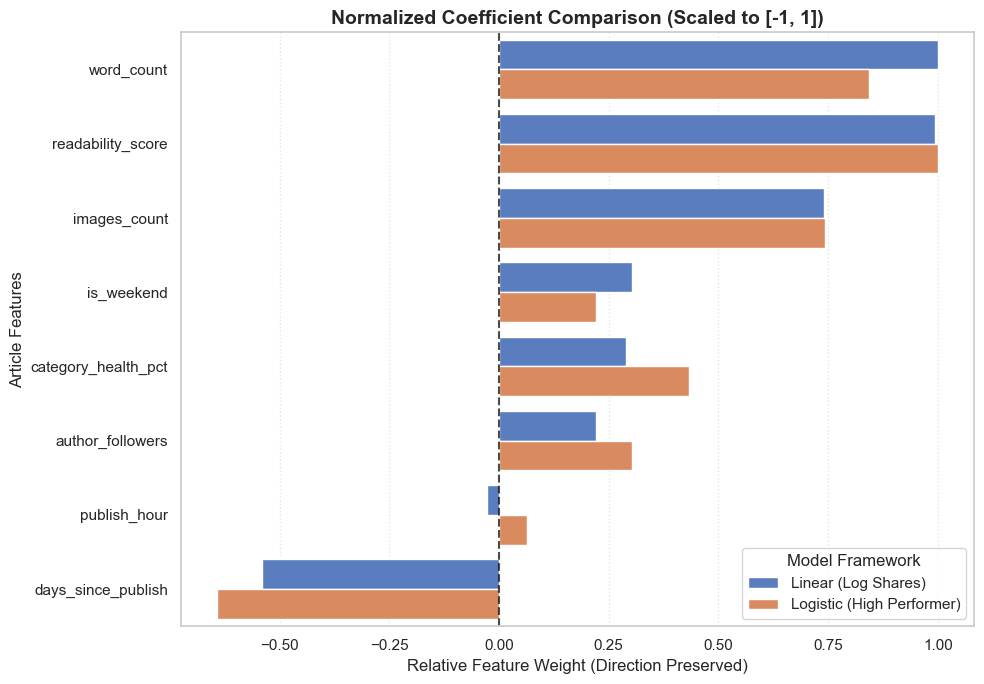

In [106]:
# (b) Standardise both coefficient sets to [-1, 1] for fair visual comparison.
#     Plot as a grouped horizontal bar chart.

# Extract raw coefficients (flattening the logistic array)
lin_coefs = lin_model.coef_
log_coefs = log_model.coef_.flatten()

# Scale both vectors to [-1, 1] by dividing by their maximum absolute value
lin_scaled = lin_coefs / np.max(np.abs(lin_coefs))
log_scaled = log_coefs / np.max(np.abs(log_coefs))

# Construct a long-form DataFrame for Seaborn
df_norm = pd.DataFrame({
    'Feature': list(X.columns) * 2,
    'Standardized Coefficient': np.concatenate([lin_scaled, log_scaled]),
    'Model Type': ['Linear (Log Shares)'] * len(X.columns) + ['Logistic (High Performer)'] * len(X.columns)
})

# Sort the features by the linear model's impact for a clean visual hierarchy
feature_order = df_norm[df_norm['Model Type'] == 'Linear (Log Shares)'].sort_values('Standardized Coefficient', ascending=False)['Feature']

# Plot Grouped Horizontal Bar Chart
plt.figure(figsize=(10, 7))

sns.barplot(
    data=df_norm,
    y='Feature',
    x='Standardized Coefficient',
    hue='Model Type',
    order=feature_order,
    palette='muted'
)

# Add a vertical reference line at zero
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('Normalized Coefficient Comparison (Scaled to [-1, 1])', fontweight='bold', fontsize=14)
plt.xlabel('Relative Feature Weight (Direction Preserved)')
plt.ylabel('Article Features')
plt.legend(title='Model Framework', loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [109]:
# (c) Fit LogisticRegression with C=0.01 and C=100. Compare coefficient magnitudes.


# 1. Fit both models under identical conditions with opposite C values
# C=0.01 implies strong regularization, C=100 implies weak/no regularization
log_strong = LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=420).fit(X_train_scaled, y_train)
log_weak   = LogisticRegression(C=100.0, solver='lbfgs', max_iter=1000, random_state=420).fit(X_train_scaled, y_train)

# 2. Compile into a comparative DataFrame
reg_df = pd.DataFrame({
    'Feature': X.columns,
    'Strong L2 (C=0.01)': log_strong.coef_.flatten(),
    'Weak L2 (C=100.0)': log_weak.coef_.flatten()
})

print("--- REGULARIZATION INTENSITY COMPARISON ---")
print(reg_df.to_string(index=False, formatters={
    'Strong L2 (C=0.01)': '{:+.4f}'.format,
    'Weak L2 (C=100.0)': '{:+.4f}'.format
}))

--- REGULARIZATION INTENSITY COMPARISON ---
            Feature Strong L2 (C=0.01) Weak L2 (C=100.0)
         word_count            +0.0217           +0.0266
  readability_score            +0.0228           +0.0281
       publish_hour            -0.0127           -0.0155
       images_count            -0.0229           -0.0279
   author_followers            +0.0400           +0.0480
 days_since_publish            -0.0106           -0.0131
         is_weekend            -0.0216           -0.0264
category_health_pct            -0.0067           -0.0080


```
#     What does this tell you about regularisation? 
1/ Inverse Relationship of C: Because C is the inverse of regularization strength (C = 1/lambda), setting a tiny value like C=0.01 applies a heavy mathematical penalty that forcefully pulls all feature coefficients inward closer to zero.

2/ Proportional Dampening (L2 Mechanics): The stronger penalty dampens every single coefficient but does not drop any of them to exactly zero. It smooths out the model's reliance on any single feature.

3/ Overfitting Control: Regularization prevents a machine learning model from overreacting to sample variance or outlier noise in your training dataset. By suppressing the raw magnitude of the weights, it reduces the complexity of the decision boundary, helping the final pipeline generalize better to unseen production data.

```
# (d) Business interpretation: write a 3-bullet summary of what drives article
#     performance at HealthLine based on the coefficients.

1/ Optimize for Length and Readability: Longer, highly readable articles are our primary traffic engines. A one-standard-deviation increase in word_count and readability_score multiplies the odds of an article becoming a top performer by 1.51 and 1.63 respectively, meaning in-depth, easy-to-read content should be our core editorial standard.

2/ Incorporate Visual Elements and Health Context: Enhancing our storytelling drives clear business value. Adding images (images_count, odds ratio 1.44) and slanting content explicitly toward health topics (category_health_pct, odds ratio 1.24) substantially lifts performance, while weekend publishing provides a small, helpful bonus.

3/ Counteract Steady Content Decay: Time is your steepest headwind. The popularity of articles experiences a significant decay over time (days_since_publish drops odds to 0.73 per standard deviation), proving that we must implement active content-refresh cycles or re-distribution campaigns for older articles to maintain steady traffic benchmarks.
